# SPATA2-inspired AnnData spatial utilities in OmicVerse

`ov.space` carries a small AnnData-native slice of the SPATA2 coordinate,
variable, outline and outlier workflows. This notebook runs every one of those
eight functions on the slide SPATA2 itself ships, so each result can be held
against the R package rather than only against the notebook that produced it.

- API PR: [omicverse/omicverse#847](https://github.com/omicverse/omicverse/pull/847)
- Rewrite repository: [omicverse/py-SPATA2](https://github.com/omicverse/py-SPATA2)
- SPATA2 documentation: [theMILOlab.github.io/SPATA2](https://themilolab.github.io/SPATA2/index.html)
- The vignette this data comes from: [initiation & preprocessing, customized](https://themilolab.github.io/SPATA2/articles/initiation-and-preprocessing-customized.html)

This is a helper layer, not a port. The last section gives the audited coverage
number so nobody reads it as one.

## What this notebook covers

| Spatial task | `ov.space` function | Output |
|---|---|---|
| Coordinate table | `spata2_get_coords` | observation-indexed `DataFrame` |
| Variables beside coordinates | `spata2_extract_variables`, `spata2_join_variables` | `obs` columns and gene values in one frame |
| Tissue outline | `spata2_tissue_outline` | hull vertices, written to `adata.uns` |
| Spatially isolated spots | `spata2_identify_outliers` | boolean flag in `adata.obs` |
| Cleaned object | `spata2_remove_outliers` | filtered `AnnData` |
| Pixel scale | `spata2_pixels_to_unit`, `spata2_unit_to_pixels` | explicit distance conversion |

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

%config InlineBackend.figure_format = 'retina'

## The slide

`ov.datasets.spata2_example()` returns the `example_data` that ships with
theMILOlab/SPATA2 v3.1.4 — the object that package's own initiation vignette is
built on. Counts and coordinates are carried over unchanged from the R object's
`count_mtr` and `coords_df`.

The histology images in the source `.rda` are not included. They are S4 EBImage
objects, which is also the reason that `.rda` cannot be read from Python at all
and had to be converted once through R.

In [2]:
adata = ov.datasets.spata2_example()
adata

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔍 Downloading data to ./data/spata2_example.h5ad


Downloading: |          | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.47M [00:00<?, ?B/s]

Downloading: 100%|█████████▉| 2.47M/2.47M [00:00<00:00, 8.24MB/s]

✅ Download completed


AnnData object with n_obs × n_vars = 3733 × 2000
    obs: 'x', 'y', 'total_counts', 'n_genes'
    uns: 'r_tissue_outline', 'source'
    obsm: 'spatial'

In [3]:
src = adata.uns['source']
print(f"{src['dataset']} from {src['package']}, file {src['file']}")
print(f"{adata.n_obs:,} spots x {adata.n_vars:,} genes, {int(adata.X.sum()):,} counts")

SPATA2 example_data from theMILOlab/SPATA2 v3.1.4, file data/example_data.rda
3,733 spots x 2,000 genes, 3,494,849 counts


## Coordinates

`spata2_get_coords` reads `adata.obsm['spatial']` and returns a tidy table. With
`include_obs` it appends observation metadata, while protecting the three columns
it owns — `barcode`, `x`, `y`. This slide carries its own `x`/`y` in `obs`, which
is exactly the collision that protection exists for: the returned `x` and `y` are
the coordinates, not the `obs` columns of the same name.

In [4]:
coords_df = ov.space.spata2_get_coords(adata, include_obs=['total_counts', 'n_genes'])
coords_df.head()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


,barcode,x,y,total_counts,n_genes
AAACAAGTATCTCCCA-1,AAACAAGTATCTCCCA-1,434.76,226.20,566,211
AAACACCAATAACTGC-1,AAACACCAATAACTGC-1,131.76,171.24,937,369
AAACAGAGCGACTCCT-1,AAACAGAGCGACTCCT-1,407.16,454.80,902,261
AAACAGCTTTCAGAAG-1,AAACAGCTTTCAGAAG-1,96.00,273.00,1576,385
AAACAGGGTCTATATT-1,AAACAGGGTCTATATT-1,110.40,247.44,1459,416


In [5]:
same_as_obsm = np.allclose(coords_df[['x', 'y']].to_numpy(), adata.obsm['spatial'])
print(f"x/y came from obsm['spatial'], not from obs: {same_as_obsm}")
print(f"columns: {list(coords_df.columns)}")

x/y came from obsm['spatial'], not from obs: True
columns: ['barcode', 'x', 'y', 'total_counts', 'n_genes']


## Variables beside the coordinates

`spata2_extract_variables` pulls `obs` columns and gene expression into one frame
and `spata2_join_variables` puts that frame next to the coordinates, which is the
shape most spatial plotting wants.

In [6]:
top_genes = adata.var_names[np.asarray(adata.X.sum(axis=0)).ravel().argsort()[::-1][:3]]
feature_df = ov.space.spata2_join_variables(adata, list(top_genes) + ['total_counts'])
print(f"three most-expressed genes: {list(top_genes)}")
feature_df.head()

three most-expressed genes: ['SEC61G', 'MT3', 'GAPDH']


,barcode,x,y,SEC61G,MT3,GAPDH,total_counts
AAACAAGTATCTCCCA-1,AAACAAGTATCTCCCA-1,434.76,226.20,151,28,6,566
AAACACCAATAACTGC-1,AAACACCAATAACTGC-1,131.76,171.24,62,55,23,937
AAACAGAGCGACTCCT-1,AAACAGAGCGACTCCT-1,407.16,454.80,111,114,23,902
AAACAGCTTTCAGAAG-1,AAACAGCTTTCAGAAG-1,96.00,273.00,280,77,21,1576
AAACAGGGTCTATATT-1,AAACAGGGTCTATATT-1,110.40,247.44,201,90,31,1459


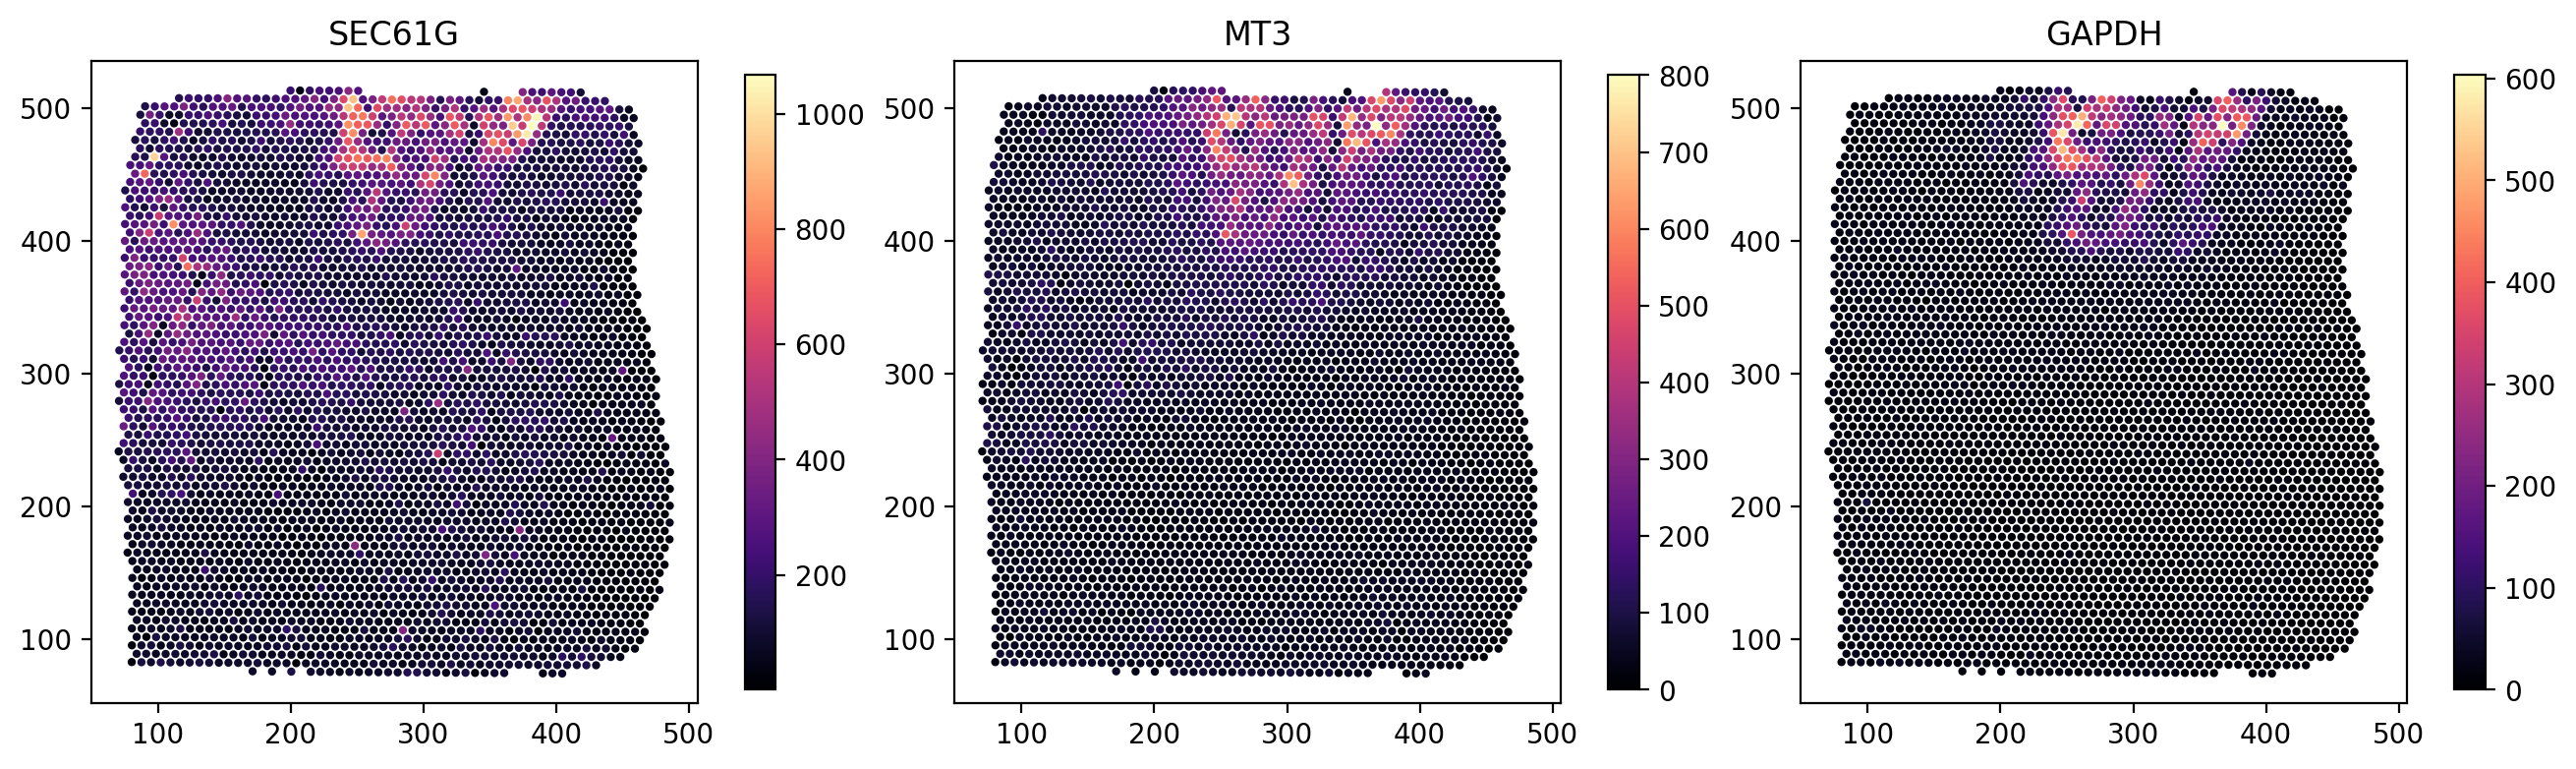

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, gene in zip(axes, top_genes):
    s = ax.scatter(feature_df['x'], feature_df['y'], c=feature_df[gene], s=4, cmap='magma')
    ax.set_title(gene); ax.set_aspect('equal'); fig.colorbar(s, ax=ax, shrink=0.8)
plt.show()

## Tissue outline

`spata2_tissue_outline` returns a **convex** hull of the spots and writes it to
`adata.uns`.

SPATA2's `identifyTissueOutline(method = "obs")` does something different: it runs
`concaveman(concavity = 2)`, and separately assigns every spot a `tissue_section`
with DBSCAN so a slide carrying several fragments produces one outline per
fragment. The dataset carries SPATA2's own answer in
`adata.uns['r_tissue_outline']` — the vertices `concaveman::concaveman(concavity = 2)`
produced under R 4.4 on these exact coordinates — so the two can be laid over
each other here without needing R.

In [8]:
outline = ov.space.spata2_tissue_outline(adata)
r_outline = adata.uns['r_tissue_outline']
print(f"ov.space convex hull: {len(outline)} vertices")
print(f"R SPATA2 concaveman : {len(r_outline)} vertices")
print(f"written to adata.uns: {[k for k in adata.uns if 'outline' in k]}")

ov.space convex hull: 34 vertices
R SPATA2 concaveman : 170 vertices
written to adata.uns: ['r_tissue_outline', 'spata2_tissue_outline', 'spata2_tissue_outline_source_obs']


In [9]:
def polygon_area(pts):
    x, y = np.asarray(pts)[:, 0], np.asarray(pts)[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

a_convex, a_concave = polygon_area(outline[['x', 'y']]), polygon_area(r_outline)
print(f"convex hull area   {a_convex:12,.1f}")
print(f"SPATA2 outline area{a_concave:12,.1f}")
print(f"the convex hull is {a_convex / a_concave:.3f}x the tissue SPATA2 outlines")

convex hull area      173,041.8
SPATA2 outline area   168,821.6
the convex hull is 1.025x the tissue SPATA2 outlines


In [10]:
def compare_outlines(spatial, r_pts, py_pts):
    ring = lambda p: np.vstack([np.asarray(p, float), np.asarray(p, float)[:1]])
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.scatter(spatial[:, 0], spatial[:, 1], s=3, c='#d0d0d0')
    ax.plot(*ring(r_pts).T, lw=2.4, c='#d62728', label='R SPATA2 concaveman(2)')
    ax.plot(*ring(py_pts).T, lw=1.8, c='#1f77b4', ls='--', label='ov.space convex hull')
    ax.set_aspect('equal')
    ax.legend(loc='lower left')
    return ax

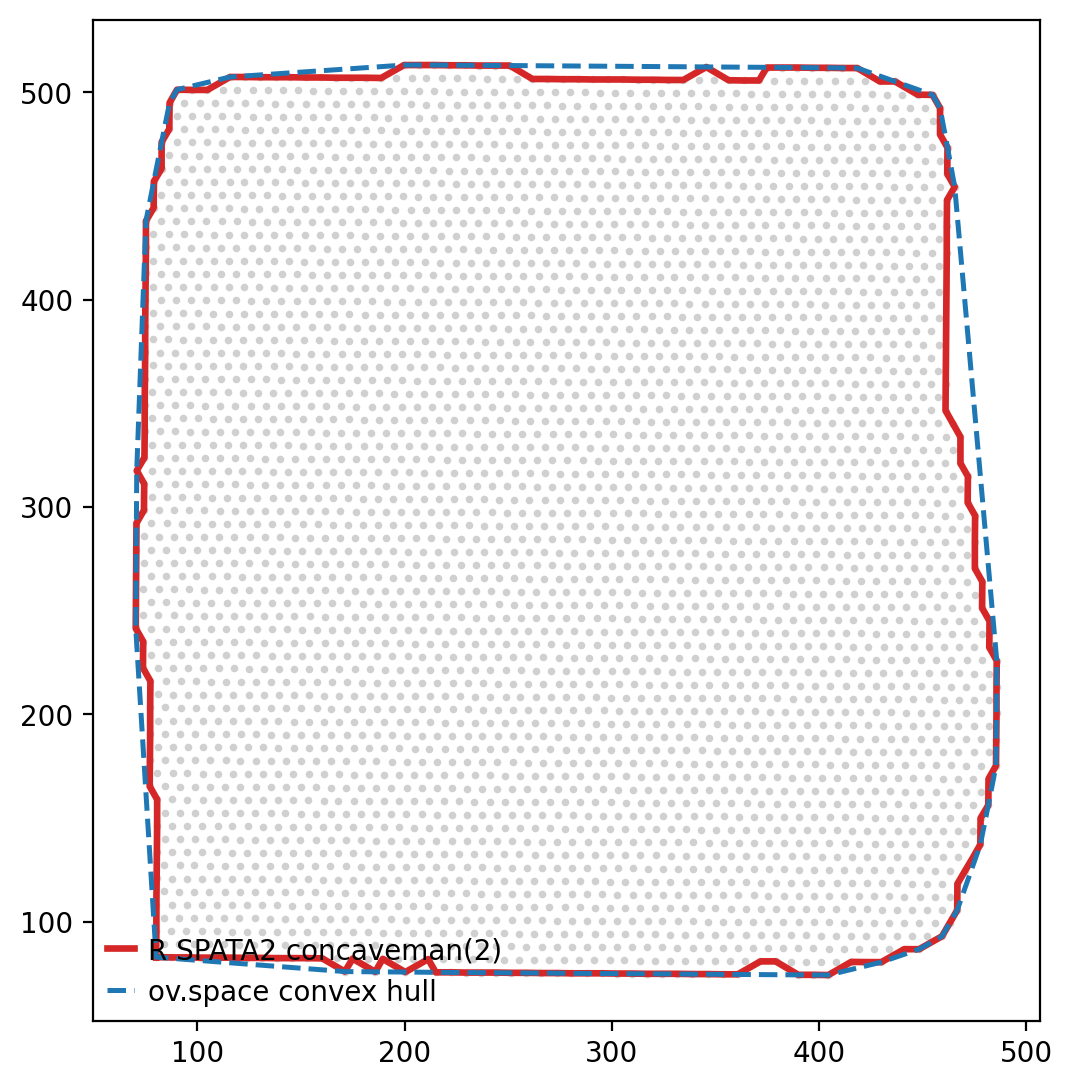

In [11]:
compare_outlines(adata.obsm['spatial'], r_outline, outline[['x', 'y']].to_numpy())
plt.show()

The two track each other closely on this slide, because the spots fill the
capture area and the point cloud is already near-convex. Measured on a second
real slide as well:

| slide | spots | convex | concaveman(2) | ratio |
|---|---|---|---|---|
| SPATA2 `example_data` | 3,733 | 173,041.8 | 168,821.6 | 1.025 |
| DLPFC 151673 | 4,910 | 316,686,266 | 316,430,828 | 1.001 |

DBSCAN finds a single tissue section and no noise spots in both, so the
per-section decomposition would have changed nothing either. Do not carry that
conclusion to a slide whose tissue is genuinely concave, or that holds more than
one fragment: a convex hull bridges the opening and merges the fragments.

## Spatially isolated spots

`spata2_identify_outliers` defaults to `method='dbscan'` — the rule SPATA2 applies
in `identifyTissueOutline(method = "obs")`, with `eps` at 1.25x the
centre-to-centre spot distance. Density connectivity is transitive, so a spot at
the rim of the tissue stays attached to the section through its neighbours.

In [12]:
flags = ov.space.spata2_identify_outliers(adata)
print(f"flagged {int(flags.sum())} of {adata.n_obs:,} spots")

flagged 0 of 3,733 spots


Zero, which is the right answer for an intact section that fills its capture area.

That is worth checking rather than assuming, so plant five spots well off the
tissue and confirm the rule finds exactly those and nothing else.

In [13]:
import anndata as ad
far = adata.obsm['spatial'].max(axis=0) + np.array([[80., 80.], [95., 70.],
                                                    [110., 90.], [70., 105.], [130., 60.]])
probe = ad.AnnData(np.zeros((adata.n_obs + 5, 1), dtype=np.float32))
probe.obsm['spatial'] = np.vstack([adata.obsm['spatial'], far])

In [14]:
probe_flags = ov.space.spata2_identify_outliers(probe, write_key=None).to_numpy()
print(f"flagged in total          : {int(probe_flags.sum())}")
print(f"of the five planted spots : {int(probe_flags[-5:].sum())}")
print(f"false positives elsewhere : {int(probe_flags[:-5].sum())}")

flagged in total          : 5
of the five planted spots : 5
false positives elsewhere : 0


`method='mad'` keeps the older rule — flag a spot whose k-th neighbour is further
than a median/MAD threshold. It is not the default, and this slide is why. Spots
sit on a regular lattice, so every interior spot has the same k-th neighbour
distance and the deviation is zero in exact arithmetic but ~1e-14 in floating
point. An earlier version tested `mad == 0`, which never fired; the threshold
collapsed onto the median and **880 of these 3,733 spots came back flagged**, all
of them intact tissue. `spata2_remove_outliers` would have deleted a quarter of
the section.

That guard is now a relative tolerance, but the rule still has no power on a
lattice — once the spread is genuinely degenerate nothing can exceed the
threshold. Keep it for irregularly sampled coordinates.

In [15]:
mad_flags = ov.space.spata2_identify_outliers(probe, method='mad', write_key=None)
print(f"method='mad' on the same probe: {int(mad_flags.sum())} flagged "
      f"({int(mad_flags.to_numpy()[-5:].sum())} of the five planted)")

method='mad' on the same probe: 0 flagged (0 of the five planted)

## Removing them

`spata2_remove_outliers` drops whatever was flagged. On this slide nothing is,
so the object comes back whole — which is the point.

In [16]:
kept = ov.space.spata2_remove_outliers(adata, copy=True)
print(f"{adata.n_obs:,} spots in, {kept.n_obs:,} out")

3,733 spots in, 3,733 out


In [17]:
probe_kept = ov.space.spata2_remove_outliers(probe, copy=True)
print(f"the probe with five planted spots: {probe.n_obs:,} in, {probe_kept.n_obs:,} out")

the probe with five planted spots: 3,738 in, 3,733 out


## Pixel scale

Coordinates here are pixels of the source image. `spata2_pixels_to_unit` and
`spata2_unit_to_pixels` make the conversion explicit rather than leaving a bare
factor in the analysis, and are exact inverses.

In [18]:
pixels_per_unit = 2.5
step = np.median(np.linalg.norm(np.diff(np.sort(adata.obsm['spatial'][:, 0])), axis=0))
distances = np.array([0.0, 55.0, 110.0, 220.0])
units = ov.space.spata2_pixels_to_unit(distances, pixels_per_unit=pixels_per_unit)
pd.DataFrame({'pixels': distances, 'units': units})

,pixels,units
0,0.0,0.0
1,55.0,22.0
2,110.0,44.0
3,220.0,88.0


In [19]:
back = ov.space.spata2_unit_to_pixels(units, pixels_per_unit=pixels_per_unit)
print(f"round-trip exact: {np.array_equal(back, distances)}")

round-trip exact: True


## Timing on this slide

In [20]:
import time

def timed(label, call):
    start = time.perf_counter()
    result = call()
    return {'operation': label, 'seconds': round(time.perf_counter() - start, 4),
            'shape': getattr(result, 'shape', (len(result),))}

In [21]:
rows = [
    timed('spata2_get_coords', lambda: ov.space.spata2_get_coords(adata)),
    timed('spata2_extract_variables', lambda: ov.space.spata2_extract_variables(adata, list(top_genes))),
    timed('spata2_join_variables', lambda: ov.space.spata2_join_variables(adata, list(top_genes))),
    timed('spata2_tissue_outline', lambda: ov.space.spata2_tissue_outline(adata, write_key=None)),
    timed('spata2_identify_outliers', lambda: ov.space.spata2_identify_outliers(adata, write_key=None)),
]
pd.DataFrame(rows)

,operation,seconds,shape
0,spata2_get_coords,0.0004,"(3733, 3)"
1,spata2_extract_variables,0.0043,"(3733, 3)"
2,spata2_join_variables,0.0045,"(3733, 6)"
3,spata2_tissue_outline,0.0022,"(34, 2)"
4,spata2_identify_outliers,0.0129,"(3733,)"


## How much of SPATA2 this is

The rewrite repository audits the real SPATA2 3.1.4 `NAMESPACE`, not a hand-picked
subset: a symbol counts as implemented only when Python exposes the same R export
name. Full tables in
[NAMESPACE_PARITY.md](https://github.com/omicverse/py-SPATA2/blob/master/NAMESPACE_PARITY.md)
and
[spata2_namespace_parity.csv](https://github.com/omicverse/py-SPATA2/blob/master/references/spata2_namespace_parity.csv).

In [22]:
pd.DataFrame(
    [['R exports audited from the SPATA2 3.1.4 NAMESPACE', '751'],
     ['R-compatible Python symbols in py-SPATA2', '16'],
     ['strict namespace coverage', '2.1%'],
     ['ov.space functions exercised in this notebook', '8']],
    columns=['metric', 'value'],
)

,metric,value
0,R exports audited from the SPATA2 3.1.4 NAMESPACE,751
1,R-compatible Python symbols in py-SPATA2,16
2,strict namespace coverage,2.1%
3,ov.space functions exercised in this notebook,8


## What to take from this

These helpers are good for coordinate inspection, variable tables, a quick tissue
boundary and isolated-spot filtering on AnnData. Two things this notebook
established that are worth carrying forward:

- the outline is convex, and on a slide that fills its capture area that is within
  2.5% of what SPATA2 draws — but a concave tissue or a multi-fragment slide is a
  different story, and neither slide tested here is one;
- the outlier rule is DBSCAN density connectivity because the median/MAD rule
  cannot work on a lattice; that was not visible until the helpers were run on a
  real slide rather than on constructed coordinates.

Coverage against the audited SPATA2 export surface is 2.1%. Treat this as a
utility layer, not a port.